# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Guntur Budi Santoso
- **Email:** budiibos0618@gmail.com
- **ID Dicoding:** CDCC899D6Y1679

## Menentukan Pertanyaan Bisnis

### **Pertanyaan 1: Bagaimana tren volume penjualan dan total pendapatan perusahaan secara bulanan?**

**Alasan:**
Memahami tren penjualan dari waktu ke waktu adalah dasar untuk mengevaluasi kesehatan bisnis. Dengan melihat tren bulanan, kita dapat mengidentifikasi musim penjualan tinggi (*peak season*) dan musim sepi (*low season*). Informasi ini sangat berguna untuk perencanaan inventaris, alokasi anggaran pemasaran, dan strategi promosi yang tepat waktu.

**Metrik yang Diperlukan:**
- Jumlah pesanan per bulan.
- Total pendapatan (*revenue*) per bulan.

---

### **Pertanyaan 2: Kategori produk apa yang paling laris dan memberikan kontribusi pendapatan terbesar?**

**Alasan:**
Tidak semua produk diciptakan sama. Beberapa kategori mungkin mendominasi penjualan. Analisis ini membantu tim bisnis untuk fokus pada kategori unggulan, mengoptimalkan stok, dan merancang kampanye pemasaran yang lebih efektif. Selain itu, dapat juga mengidentifikasi kategori yang kurang diminati untuk dievaluasi ulang.

**Metrik yang Diperlukan:**
- Total kuantitas barang terjual per kategori produk (dalam bahasa Inggris).
- Total pendapatan per kategori produk.

---

### **Pertanyaan 3: Bagaimana tingkat kepuasan pelanggan berdasarkan skor ulasan (*review score*)? Apakah ada hubungan antara skor ulasan dengan waktu pengiriman atau kategori produk?**

**Alasan:**
Ulasan pelanggan adalah cerminan kualitas layanan. Skor rendah dapat mengindikasikan masalah pada produk atau logistik. Dengan menganalisis hubungan antara skor ulasan dengan waktu pengiriman atau kategori produk, kita dapat mengidentifikasi akar permasalahan yang memengaruhi kepuasan pelanggan dan mengambil tindakan perbaikan yang spesifik.

**Metrik yang Diperlukan:**
- Distribusi skor ulasan (1 hingga 5).
- Rata-rata skor ulasan per kategori produk.
- Rata-rata waktu pengiriman (dalam hari) untuk setiap kelompok skor ulasan.

---

### **Pertanyaan 4: Bagaimana pola pembayaran yang digunakan oleh pelanggan? Apakah ada perbedaan nilai transaksi antara metode pembayaran atau jumlah cicilan?**

**Alasan:**
Metode pembayaran dan opsi cicilan dapat memengaruhi keputusan pembelian, terutama untuk barang dengan harga tinggi. Memahami preferensi pembayaran pelanggan membantu perusahaan dalam mengoptimalkan pengalaman *checkout* dan menjalin kerja sama yang lebih baik dengan penyedia layanan pembayaran. Analisis ini juga dapat mengungkap segmen pelanggan yang cenderung menggunakan cicilan untuk pembelian bernilai besar.

**Metrik yang Diperlukan:**
- Proporsi penggunaan setiap metode pembayaran (*credit_card*, *boleto*, *voucher*, *debit_card*).
- Rata-rata nilai transaksi per metode pembayaran.
- Rata-rata nilai transaksi berdasarkan jumlah cicilan (*payment_installments*).

---

### **Pertanyaan 5 (Analisis Lanjutan - RFM): Bagaimana segmentasi pelanggan berdasarkan perilaku pembelian mereka (Recency, Frequency, Monetary)?**

**Alasan:**
Tidak semua pelanggan bernilai sama. Analisis RFM adalah teknik pemasaran klasik yang mengelompokkan pelanggan berdasarkan **Recency** (kapan terakhir kali membeli), **Frequency** (seberapa sering membeli), dan **Monetary** (berapa total uang yang dibelanjakan). Dengan segmentasi ini, perusahaan dapat merancang strategi yang personal: memberikan *reward* untuk pelanggan terbaik, menawarkan diskon untuk mengaktifkan kembali pelanggan yang hampir hilang, atau memberikan perhatian khusus pada pelanggan baru.

**Metrik yang Diperlukan (per pelanggan unik):**
- **Recency:** Jumlah hari sejak pembelian terakhir hingga tanggal analisis.
- **Frequency:** Jumlah total pesanan unik yang telah di

## Import Semua Packages/Library yang Digunakan

In [1]:
# Data Manipulation & Analysis
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date & Time Handling
from datetime import datetime, timedelta

# Geospatial Analysis (Opsional)
import folium
from folium.plugins import MarkerCluster

# Additional Visualization for Dashboard
import plotly.express as px
import plotly.graph_objects as go

# Streamlit Dashboard
!pip install -q pandas numpy matplotlib seaborn plotly folium streamlit
import streamlit as st

# Suppress Warnings (Opsional - agar output lebih bersih)
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi matplotlib/seaborn
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 72.1 MB/s eta 0:00:00


## Data Wrangling

### Gathering Data

In [2]:
# =====================================================
# GATHERING DATA
# =====================================================

# Daftar nama file dataset
files = [
    'customers_dataset.csv',
    'geolocation_dataset.csv',
    'order_items_dataset.csv',
    'order_payments_dataset.csv',
    'order_reviews_dataset.csv',
    'orders_dataset.csv',
    'product_category_name_translation.csv',
    'products_dataset.csv',
    'sellers_dataset.csv'
]

# Membaca semua file ke dalam dictionary of DataFrames
dataframes = {}

for file in files:
    # Nama dataframe tanpa ekstensi .csv
    df_name = file.replace('_dataset.csv', '').replace('.csv', '')
    try:
        dataframes[df_name] = pd.read_csv(file)
        print(f"Berhasil membaca {file} -> shape: {dataframes[df_name].shape}")
    except FileNotFoundError:
        print(f"File {file} tidak ditemukan. Pastikan file sudah diunggah ke Colab.")

# Menampilkan daftar dataframe yang tersedia
print("\n Dataframe yang tersedia:")
for name, df in dataframes.items():
    print(f"  - {name}: {df.shape[0]} baris, {df.shape[1]} kolom")

✅ Berhasil membaca customers_dataset.csv -> shape: (99441, 5)
✅ Berhasil membaca geolocation_dataset.csv -> shape: (1000163, 5)
✅ Berhasil membaca order_items_dataset.csv -> shape: (112650, 7)
✅ Berhasil membaca order_payments_dataset.csv -> shape: (103886, 5)
✅ Berhasil membaca order_reviews_dataset.csv -> shape: (99224, 7)
✅ Berhasil membaca orders_dataset.csv -> shape: (99441, 8)
✅ Berhasil membaca product_category_name_translation.csv -> shape: (71, 2)
✅ Berhasil membaca products_dataset.csv -> shape: (32951, 9)
✅ Berhasil membaca sellers_dataset.csv -> shape: (3095, 4)

 Dataframe yang tersedia:
  - customers: 99441 baris, 5 kolom
  - geolocation: 1000163 baris, 5 kolom
  - order_items: 112650 baris, 7 kolom
  - order_payments: 103886 baris, 5 kolom
  - order_reviews: 99224 baris, 7 kolom
  - orders: 99441 baris, 8 kolom
  - product_category_name_translation: 71 baris, 2 kolom
  - products: 32951 baris, 9 kolom
  - sellers: 3095 baris, 4 kolom


**Insight:**
**Insight Awal Gathering Data:**

- **Ukuran Dataset Bervariasi Signifikan**  
  Dataset `geolocation` memiliki volume data terbesar (~992 ribu baris) karena menyimpan informasi koordinat untuk setiap kode pos di Brasil. Dataset ini akan berguna jika kita melakukan analisis geospasial. Sebaliknya, dataset `product_category_name_translation` hanya berisi 71 baris sebagai tabel referensi untuk menerjemahkan nama kategori produk.

- **Dataset Inti Transaksional**  
  Dataset `orders` (99.441 baris), `order_items` (112.650 baris), `order_payments` (103.886 baris), dan `order_reviews` (99.224 baris) saling berelasi melalui kolom `order_id`. Satu pesanan (`orders`) dapat memiliki beberapa item (`order_items`), beberapa metode pembayaran (`order_payments`), dan beberapa ulasan (`order_reviews`). Relasi *one-to-many* ini akan menjadi kunci utama dalam proses penggabungan data.

- **Perbedaan Jumlah Baris Antar Dataset Terkait**  
  Terdapat perbedaan jumlah baris antara `orders` (99.441) dan `order_items` (112.650). Ini wajar karena satu `order_id` bisa memuat lebih dari satu produk. Namun, perlu diperiksa apakah semua `order_id` pada `order_items` memiliki induk di tabel `orders` (data integrity check). Hal serupa juga perlu dilakukan pada `order_payments` dan `order_reviews`.

- **Dataset Master (Dimensi)**  
  Dataset `customers`, `products`, `sellers`, dan `product_category_name_translation` berfungsi sebagai data master/dimensi. Jumlah barisnya relatif kecil dan akan digunakan untuk memperkaya informasi pada tabel transaksi.

- **Kesiapan Data untuk Tahap Selanjutnya**  
  Semua file berhasil dibaca tanpa error, menandakan struktur file CSV konsisten. Namun, kita belum memeriksa adanya *missing value*, duplikasi, atau inkonsistensi tipe data. Oleh karena itu, langkah berikutnya adalah **Assessing Data** untuk mengevaluasi kualitas data secara menyeluruh.

### Assessing Data

In [3]:
# =====================================================
# Fungsi Bantu untuk Assessing Data
# =====================================================

def assess_data(df, name):
    """
    Fungsi untuk menampilkan ringkasan penilaian kualitas data sebuah DataFrame.
    """
    print("=" * 70)
    print(f"ASSESSING DATASET: {name.upper()}")
    print("=" * 70)

    # 1. Informasi Dasar
    print(f"\n🔹 Shape (Baris, Kolom): {df.shape}")

    # 2. Tipe Data
    print("\n🔹 Tipe Data Setiap Kolom:")
    print(df.dtypes)

    # 3. Missing Values
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({
        'Missing_Count': missing,
        'Percentage (%)': missing_pct.round(2)
    })
    missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

    if len(missing_df) > 0:
        print("\n🔹 Missing Values:")
        print(missing_df)
    else:
        print("\n🔹 Missing Values: Tidak ada missing value ")

    # 4. Duplikasi Data
    duplicates = df.duplicated().sum()
    print(f"\n🔹 Jumlah Baris Duplikat: {duplicates}")

    # 5. Statistik Deskriptif untuk Kolom Numerik
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    if numeric_cols:
        print("\n🔹 Statistik Deskriptif (Kolom Numerik):")
        display(df[numeric_cols].describe())

    # 6. Tampilkan beberapa nilai unik untuk kolom kategorikal
    cat_cols = df.select_dtypes(include=['object']).columns.tolist()
    if cat_cols:
        print("\n🔹 Contoh Nilai Unik (5 pertama) untuk Kolom Kategorikal:")
        for col in cat_cols[:5]:  # Batasi hanya 5 kolom pertama agar tidak terlalu panjang
            unique_sample = df[col].dropna().unique()[:5]
            print(f"   - {col}: {unique_sample}")

    print("\n" + "-" * 70 + "\n")

# Jalankan fungsi assess_data untuk setiap DataFrame dalam dictionary `dataframes`
for name, df in dataframes.items():
    assess_data(df, name)

ASSESSING DATASET: CUSTOMERS

🔹 Shape (Baris, Kolom): (99441, 5)

🔹 Tipe Data Setiap Kolom:
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

🔹 Missing Values: Tidak ada missing value 

🔹 Jumlah Baris Duplikat: 0

🔹 Statistik Deskriptif (Kolom Numerik):


,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000



🔹 Contoh Nilai Unik (5 pertama) untuk Kolom Kategorikal:
   - customer_id: ['06b8999e2fba1a1fbc88172c00ba8bc7' '18955e83d337fd6b2def6b18a428ac77'
 '4e7b3e00288586ebd08712fdd0374a03' 'b2b6027bc5c5109e529d4dc6358b12c3'
 '4f2d8ab171c80ec8364f7c12e35b23ad']
   - customer_unique_id: ['861eff4711a542e4b93843c6dd7febb0' '290c77bc529b7ac935b93aa66c333dc3'
 '060e732b5b29e8181a18229c7b0b2b5e' '259dac757896d24d7702b9acbbff3f3c'
 '345ecd01c38d18a9036ed96c73b8d066']
   - customer_city: ['franca' 'sao bernardo do campo' 'sao paulo' 'mogi das cruzes' 'campinas']
   - customer_state: ['SP' 'SC' 'MG' 'PR' 'RJ']

----------------------------------------------------------------------

ASSESSING DATASET: GEOLOCATION

🔹 Shape (Baris, Kolom): (1000163, 5)

🔹 Tipe Data Setiap Kolom:
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                object
geolocation_state               object
dtype: object

🔹 Missing Values: 

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02



🔹 Contoh Nilai Unik (5 pertama) untuk Kolom Kategorikal:
   - geolocation_city: ['sao paulo' 'são paulo' 'sao bernardo do campo' 'jundiaí'
 'taboão da serra']
   - geolocation_state: ['SP' 'RN' 'AC' 'RJ' 'ES']

----------------------------------------------------------------------

ASSESSING DATASET: ORDER_ITEMS

🔹 Shape (Baris, Kolom): (112650, 7)

🔹 Tipe Data Setiap Kolom:
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

🔹 Missing Values: Tidak ada missing value 

🔹 Jumlah Baris Duplikat: 0

🔹 Statistik Deskriptif (Kolom Numerik):


...


🔹 Contoh Nilai Unik (5 pertama) untuk Kolom Kategorikal:
   - review_id: ['7bc2406110b926393aa56f80a40eba40' '80e641a11e56f04c1ad469d5645fdfde'
 '228ce5500dc1d8e020d8d1322874b6f0' 'e64fb393e7b32834bb789ff8bb30750e'
 'f7c4243c7fe1938f181bec41a392bdeb']
   - order_id: ['73fc7af87114b39712e6da79b0a377eb' 'a548910a1c6147796b98fdf73dbeba33'
 'f9e4b658b201a9f2ecdecbb34bed034b' '658677c97b385a9be170737859d3511b'
 '8e6bfb81e283fa7e4f11123a3fb894f1']
   - review_comment_title: ['recomendo' 'Super recomendo' 'Não chegou meu produto ' 'Ótimo'
 'Muito bom.']
   - review_comment_message: ['Recebi bem antes do prazo estipulado.'
 'Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos feliz Páscoa'
 'aparelho eficiente. no site a marca do aparelho esta impresso como 3desinfector e ao chegar esta com outro nome...atualizar com a marca correta uma vez que é o mesmo aparelho'
 'Mas um pouco ,travando...pelo valor ta Boa.\r\n'
 'Vendedor confiável, produto ok e entrega 

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000



🔹 Contoh Nilai Unik (5 pertama) untuk Kolom Kategorikal:
   - product_id: ['1e9e8ef04dbcff4541ed26657ea517e5' '3aa071139cb16b67ca9e5dea641aaa2f'
 '96bd76ec8810374ed1b65e291975717f' 'cef67bcfe19066a932b7673e239eb23d'
 '9dc1a7de274444849c219cff195d0b71']
   - product_category_name: ['perfumaria' 'artes' 'esporte_lazer' 'bebes' 'utilidades_domesticas']

----------------------------------------------------------------------

ASSESSING DATASET: SELLERS

🔹 Shape (Baris, Kolom): (3095, 4)

🔹 Tipe Data Setiap Kolom:
seller_id                 object
seller_zip_code_prefix     int64
seller_city               object
seller_state              object
dtype: object

🔹 Missing Values: Tidak ada missing value 

🔹 Jumlah Baris Duplikat: 0

🔹 Statistik Deskriptif (Kolom Numerik):


,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000



🔹 Contoh Nilai Unik (5 pertama) untuk Kolom Kategorikal:
   - seller_id: ['3442f8959a84dea7ee197c632cb2df15' 'd1b65fc7debc3361ea86b5f14c68d2e2'
 'ce3ad9de960102d0677a81f5d0bb7b2d' 'c0f3eea2e14555b6faeea3dd58c1b1c3'
 '51a04a8a6bdcb23deccc82b0b80742cf']
   - seller_city: ['campinas' 'mogi guacu' 'rio de janeiro' 'sao paulo' 'braganca paulista']
   - seller_state: ['SP' 'RJ' 'PE' 'PR' 'GO']

----------------------------------------------------------------------



**Insight:**
### 🔍 Temuan Utama dari Assessing Data

Berdasarkan hasil pemeriksaan kualitas data pada seluruh dataset, berikut ringkasan temuan penting yang akan ditangani pada tahap **Data Cleaning**:

---

#### 1. **Missing Values yang Perlu Ditangani**

| Dataset | Kolom | Missing Count | Persentase |
|---------|-------|---------------|------------|
| `orders` | `order_delivered_customer_date` | 2.965 | 2,98% |
| `orders` | `order_delivered_carrier_date` | 1.783 | 1,79% |
| `orders` | `order_approved_at` | 160 | 0,16% |
| `order_reviews` | `review_comment_title` | 87.656 | 88,34% |
| `order_reviews` | `review_comment_message` | 58.247 | 58,70% |
| `products` | `product_category_name` (dan kolom terkait) | 610 | 1,85% |
| `products` | `product_weight_g`, `_length_cm`, `_height_cm`, `_width_cm` | 2 | 0,01% |

**Interpretasi:**
- Missing values pada kolom tanggal di `orders` kemungkinan berasal dari pesanan yang **tidak selesai** (status selain 'delivered').
- Kolom komentar ulasan mayoritas kosong karena pembeli tidak wajib menulis teks.
- Produk dengan kategori kosong (610 baris) perlu diinvestigasi apakah dapat diisi atau dibuang.

---

#### 2. **Duplikasi Data**

- Dataset `geolocation` memiliki **261.831 baris duplikat** (≈26% dari total data). Hal ini wajar karena satu kode pos dapat memiliki beberapa koordinat. Perlu diputuskan apakah akan dihapus atau diagregasi (misal dengan rata-rata koordinat per kode pos).
- Semua dataset lain **tidak memiliki duplikasi baris penuh**.

---

#### 3. **Tipe Data yang Perlu Dikonversi**

| Dataset | Kolom | Tipe Saat Ini | Tipe Seharusnya |
|---------|-------|---------------|-----------------|
| `orders` | `order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date` | `object` | `datetime` |
| `order_items` | `shipping_limit_date` | `object` | `datetime` |
| `order_reviews` | `review_creation_date`, `review_answer_timestamp` | `object` | `datetime` |

Konversi ke `datetime` diperlukan untuk analisis tren waktu dan perhitungan selisih hari (misal: durasi pengiriman).

---

#### 4. **Anomali atau Nilai yang Perlu Diperhatikan**

- **`orders.order_status`**: Memiliki nilai seperti `'delivered'`, `'shipped'`, `'canceled'`, `'unavailable'`, `'invoiced'`, `'processing'`, `'approved'`. Analisis penjualan sebaiknya difokuskan pada pesanan dengan status **'delivered'** untuk memastikan transaksi benar-benar selesai.
- **`order_payments.payment_type`**: Terdapat nilai `'not_defined'`. Perlu dicek lebih lanjut, kemungkinan data tidak tercatat dengan baik.
- **`products`**: Ditemukan nilai **0** pada kolom `product_weight_g` dan dimensi produk. Ini tidak realistis untuk produk fisik. Mungkin perlu diimputasi atau dihapus jika jumlahnya signifikan.
- **`geolocation.geolocation_city`**: Terdapat variasi penulisan nama kota, misal `'sao paulo'` vs `'são paulo'` (dengan aksen). Dapat memengaruhi akurasi analisis per kota.

---

#### 5. **Catatan Khusus per Dataset**

- **`geolocation`**: Volume data besar (≈1 juta baris) dan duplikasi tinggi. Untuk efisiensi, akan dibuat dataframe agregat `geolocation_agg` yang berisi **rata-rata latitude dan longitude per kode pos unik**.
- **`order_reviews`**: Kolom komentar akan dipertahankan, tetapi missing value tidak akan diisi karena bersifat opsional. Analisis skor ulasan (1-5) tetap dapat dilakukan tanpa komentar.
- **`product_category_name_translation`**: Dataset bersih dan siap digunakan sebagai tabel referensi untuk menerjemahkan kategori produk ke bahasa Inggris.
- **`customers` & `sellers`**: Data master bersih, tidak ada missing value atau duplikasi. Siap digabungkan dengan tabel transaksi.

---

#### 6. **Kesimpulan Kesiapan Data**

Secara umum, dataset dalam kondisi **cukup baik** untuk dianalisis setelah dilakukan langkah pembersihan berikut:

1. Konversi kolom tanggal ke tipe `datetime`.
2. Penanganan missing value pada `orders` dan `products` (drop atau imputasi sesuai konteks).
3. Agregasi data `geolocation` untuk mengurangi redundansi.
4. Filter data transaksi hanya pada status **'delivered'** untuk analisis penjualan dan pendapatan.
5. Penggabungan dataset master dengan tabel transaksi untuk memperkaya analisis.


### Cleaning Data

In [4]:
# =====================================================
#  CLEANING DATA
# =====================================================

# ---------------------------------------------
# Step 1: Salin DataFrame Asli ke Variabel Clean
# ---------------------------------------------
# Membuat dictionary baru untuk menyimpan data yang sudah dibersihkan
clean_data = {}

for name, df in dataframes.items():
    clean_data[name] = df.copy()
    print(f"DataFrame '{name}' disalin. Shape: {clean_data[name].shape}")

# ---------------------------------------------
# Step 2: Konversi Kolom Tanggal ke datetime
# ---------------------------------------------

# 2.1 Dataset orders
date_columns_orders = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns_orders:
    clean_data['orders'][col] = pd.to_datetime(clean_data['orders'][col], errors='coerce')

print("\n Kolom tanggal pada 'orders' berhasil dikonversi ke datetime.")

# 2.2 Dataset order_items
clean_data['order_items']['shipping_limit_date'] = pd.to_datetime(
    clean_data['order_items']['shipping_limit_date'], errors='coerce'
)
print(" Kolom 'shipping_limit_date' pada 'order_items' berhasil dikonversi.")

# 2.3 Dataset order_reviews
clean_data['order_reviews']['review_creation_date'] = pd.to_datetime(
    clean_data['order_reviews']['review_creation_date'], errors='coerce'
)
clean_data['order_reviews']['review_answer_timestamp'] = pd.to_datetime(
    clean_data['order_reviews']['review_answer_timestamp'], errors='coerce'
)
print(" Kolom tanggal pada 'order_reviews' berhasil dikonversi.")

DataFrame 'customers' disalin. Shape: (99441, 5)
DataFrame 'geolocation' disalin. Shape: (1000163, 5)
DataFrame 'order_items' disalin. Shape: (112650, 7)
DataFrame 'order_payments' disalin. Shape: (103886, 5)
DataFrame 'order_reviews' disalin. Shape: (99224, 7)
DataFrame 'orders' disalin. Shape: (99441, 8)
DataFrame 'product_category_name_translation' disalin. Shape: (71, 2)
DataFrame 'products' disalin. Shape: (32951, 9)
DataFrame 'sellers' disalin. Shape: (3095, 4)

 Kolom tanggal pada 'orders' berhasil dikonversi ke datetime.
 Kolom 'shipping_limit_date' pada 'order_items' berhasil dikonversi.
 Kolom tanggal pada 'order_reviews' berhasil dikonversi.


In [5]:
# ---------------------------------------------
# Step 3: Penanganan Missing Values
# ---------------------------------------------

# 3.1 Dataset orders
# Missing pada kolom tanggal di orders sebagian besar berasal dari pesanan non-delivered.
# Kita akan biarkan NaN untuk sementara, nanti akan difilter.

print(" Missing values di 'orders' sebelum cleaning:")
print(clean_data['orders'].isnull().sum())

# 3.2 Dataset order_reviews
# Kolom komentar memiliki missing >50%, akan dibiarkan karena opsional.
# Tidak ada tindakan khusus.

# 3.3 Dataset products
# Cek missing values di products
print("\n Missing values di 'products' sebelum cleaning:")
print(clean_data['products'].isnull().sum())

# Produk dengan kategori NaN (610 baris) tidak dapat diidentifikasi kategorinya.
# Kita drop baris tersebut karena jumlahnya kecil (1.85%).
clean_data['products'] = clean_data['products'].dropna(subset=['product_category_name'])

# Missing values pada dimensi produk (2 baris) juga didrop karena jumlah sangat kecil.
dimensi_cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
clean_data['products'] = clean_data['products'].dropna(subset=dimensi_cols)

print(f"\n Baris dengan missing values di 'products' telah dihapus.")
print(f"   Shape baru: {clean_data['products'].shape}")

📊 Missing values di 'orders' sebelum cleaning:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

📊 Missing values di 'products' sebelum cleaning:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

✅ Baris dengan missing values di 'products' telah dihapus.
   Shape baru: (32340, 9)


In [6]:
# ---------------------------------------------
# Step 4: Agregasi Dataset geolocation
# ---------------------------------------------
# Karena banyak duplikasi pada zip code, kita agregasi dengan rata-rata koordinat.

print(f" Shape 'geolocation' sebelum agregasi: {clean_data['geolocation'].shape}")

# Agregasi per zip code: ambil rata-rata latitude dan longitude, serta city dan state pertama
geolocation_agg = clean_data['geolocation'].groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean',
    'geolocation_city': 'first',
    'geolocation_state': 'first'
}).reset_index()

# Simpan kembali ke clean_data
clean_data['geolocation'] = geolocation_agg

print(f" Shape 'geolocation' setelah agregasi: {clean_data['geolocation'].shape}")
print("   Duplikasi zip code telah dihapus, setiap kode pos unik memiliki satu koordinat rata-rata.")

📊 Shape 'geolocation' sebelum agregasi: (1000163, 5)
✅ Shape 'geolocation' setelah agregasi: (19015, 5)
   Duplikasi zip code telah dihapus, setiap kode pos unik memiliki satu koordinat rata-rata.


In [7]:
# ---------------------------------------------
# Step 5: Filter Data Transaksi Hanya 'delivered'
# ---------------------------------------------
# Untuk analisis penjualan, kita hanya gunakan pesanan yang berhasil terkirim.

print(f" Jumlah pesanan sebelum filter: {clean_data['orders'].shape[0]}")

# Distribusi status pesanan
print("\nDistribusi order_status:")
print(clean_data['orders']['order_status'].value_counts())

# Filter hanya status 'delivered'
orders_delivered = clean_data['orders'][clean_data['orders']['order_status'] == 'delivered'].copy()

print(f"\n Jumlah pesanan setelah filter (delivered): {orders_delivered.shape[0]}")

# Simpan kembali ke clean_data['orders'] sebagai data utama untuk analisis
clean_data['orders'] = orders_delivered

📊 Jumlah pesanan sebelum filter: 99441

Distribusi order_status:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

✅ Jumlah pesanan setelah filter (delivered): 96478


In [8]:
# ---------------------------------------------
# Step 6: Menangani Nilai Anomali pada Dimensi Produk
# ---------------------------------------------
# Beberapa produk memiliki berat atau dimensi 0 (tidak realistis).

dimensi_cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

print(" Jumlah produk dengan nilai 0 pada kolom dimensi:")
for col in dimensi_cols:
    count_zero = (clean_data['products'][col] == 0).sum()
    print(f"   - {col}: {count_zero} baris")

# Hapus baris yang memiliki nilai 0 pada kolom-kolom tersebut
mask_zero = (clean_data['products'][dimensi_cols] == 0).any(axis=1)
products_clean = clean_data['products'][~mask_zero].copy()

print(f"\n Produk dengan dimensi 0 telah dihapus.")
print(f"   Shape sebelum: {clean_data['products'].shape}")
print(f"   Shape setelah: {products_clean.shape}")

clean_data['products'] = products_clean

📊 Jumlah produk dengan nilai 0 pada kolom dimensi:
   - product_weight_g: 4 baris
   - product_length_cm: 0 baris
   - product_height_cm: 0 baris
   - product_width_cm: 0 baris

✅ Produk dengan dimensi 0 telah dihapus.
   Shape sebelum: (32340, 9)
   Shape setelah: (32336, 9)


In [9]:
# ---------------------------------------------
# Step 7: Pembersihan Tambahan
# ---------------------------------------------

# 7.1 Hapus spasi berlebih pada kolom string di customers dan sellers
for df_name in ['customers', 'sellers']:
    str_cols = clean_data[df_name].select_dtypes(include=['object']).columns
    for col in str_cols:
        clean_data[df_name][col] = clean_data[df_name][col].str.strip()

print(" Kolom string pada customers dan sellers telah dibersihkan dari spasi berlebih.")

# 7.2 Standarisasi payment_type di order_payments
print("\nDistribusi payment_type sebelum standarisasi:")
print(clean_data['order_payments']['payment_type'].value_counts())

# Ubah 'not_defined' menjadi 'unknown' agar lebih jelas
clean_data['order_payments']['payment_type'] = clean_data['order_payments']['payment_type'].replace('not_defined', 'unknown')

print("\n Nilai 'not_defined' pada payment_type diubah menjadi 'unknown'.")

✅ Kolom string pada customers dan sellers telah dibersihkan dari spasi berlebih.

Distribusi payment_type sebelum standarisasi:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

✅ Nilai 'not_defined' pada payment_type diubah menjadi 'unknown'.


In [10]:
# ---------------------------------------------
# Step 8: Verifikasi Akhir
# ---------------------------------------------

print("=" * 70)
print("VERIFIKASI HASIL CLEANING")
print("=" * 70)

for name in ['orders', 'products', 'geolocation', 'customers', 'sellers', 'order_items', 'order_payments', 'order_reviews']:
    df = clean_data[name]
    missing = df.isnull().sum().sum()
    duplicates = df.duplicated().sum()
    print(f"\n {name.upper()}")
    print(f"   - Shape: {df.shape}")
    print(f"   - Total Missing Values: {missing}")
    print(f"   - Duplicate Rows: {duplicates}")

print("\n Semua dataset telah dibersihkan dan siap untuk analisis.")

VERIFIKASI HASIL CLEANING

📁 ORDERS
   - Shape: (96478, 8)
   - Total Missing Values: 24
   - Duplicate Rows: 0

📁 PRODUCTS
   - Shape: (32336, 9)
   - Total Missing Values: 0
   - Duplicate Rows: 0

📁 GEOLOCATION
   - Shape: (19015, 5)
   - Total Missing Values: 0
   - Duplicate Rows: 0

📁 CUSTOMERS
   - Shape: (99441, 5)
   - Total Missing Values: 0
   - Duplicate Rows: 0

📁 SELLERS
   - Shape: (3095, 4)
   - Total Missing Values: 0
   - Duplicate Rows: 0

📁 ORDER_ITEMS
   - Shape: (112650, 7)
   - Total Missing Values: 0
   - Duplicate Rows: 0

📁 ORDER_PAYMENTS
   - Shape: (103886, 5)
   - Total Missing Values: 0
   - Duplicate Rows: 0

📁 ORDER_REVIEWS
   - Shape: (99224, 7)
   - Total Missing Values: 145903
   - Duplicate Rows: 0

✅ Semua dataset telah dibersihkan dan siap untuk analisis.


### Insight Setelah Data Cleaning

Berdasarkan hasil pembersihan data yang telah dilakukan, berikut ringkasan perubahan signifikan pada dataset:

---

#### 1. **Konversi Tipe Data Tanggal**
- Kolom tanggal pada dataset `orders` (5 kolom), `order_items` (`shipping_limit_date`), dan `order_reviews` (2 kolom) telah berhasil dikonversi ke tipe `datetime`.  
- Konversi ini memungkinkan perhitungan selisih waktu (misal: durasi pengiriman) dan analisis tren berbasis waktu yang akurat.

---

#### 2. **Penanganan Missing Values**
- **Dataset `orders`**:  
  Missing values ditemukan pada:
  - `order_approved_at`: 160 baris (0,16%)
  - `order_delivered_carrier_date`: 1.783 baris (1,79%)
  - `order_delivered_customer_date`: 2.965 baris (2,98%)  
  *Nilai kosong ini dibiarkan sementara karena akan otomatis tereliminasi saat filtering pesanan non‑delivered.*

- **Dataset `products`**:  
  - 610 baris memiliki `product_category_name` kosong (beserta kolom panjang nama, deskripsi, dan jumlah foto). Seluruh baris tersebut dihapus karena tidak dapat diidentifikasi kategorinya.  
  - 2 baris memiliki nilai kosong pada kolom dimensi (`weight`, `length`, `height`, `width`) → juga dihapus.  
  - **Hasil:** Shape `products` berubah dari **(32.951, 9)** menjadi **(32.340, 9)**.

---

#### 3. **Agregasi Dataset `geolocation`**
- Dataset awal memiliki **1.000.163 baris** dengan **261.831 baris duplikat** (≈26%).  
- Dilakukan agregasi dengan mengambil **rata‑rata latitude dan longitude per kode pos unik**.  
- **Hasil:** Shape `geolocation` mengecil drastis menjadi **(19.015, 5)**.  
- Setiap kode pos kini hanya memiliki satu baris data koordinat, sehingga proses penggabungan dengan data pelanggan/penjual akan jauh lebih ringan.

---

#### 4. **Filter Pesanan Berstatus 'delivered'**
- Distribusi status pesanan sebelum filter:  
  `delivered`: 96.478 | `shipped`: 1.107 | `canceled`: 625 | `unavailable`: 609 | `invoiced`: 314 | `processing`: 301 | `created`: 5 | `approved`: 2  
- Untuk analisis penjualan dan pendapatan, hanya pesanan berstatus **'delivered'** yang digunakan.  
- **Hasil:** Dataset `orders` kini hanya berisi **96.478 pesanan** (≈97% dari total awal).

---

#### 5. **Penanganan Nilai Anomali pada Dimensi Produk**
- Ditemukan produk dengan nilai **0** pada kolom:
  - `product_weight_g`: 4 baris  
  - `product_length_cm`, `product_height_cm`, `product_width_cm`: 0 baris  
- Baris dengan berat 0 dihapus karena tidak realistis untuk produk fisik.  
- **Hasil:** Shape `products` final menjadi **(32.336, 9)**.

---

#### 6. **Verifikasi Akhir Seluruh Dataset**
| Dataset | Shape Final | Missing Values | Duplicate Rows |
|---------|-------------|----------------|----------------|
| `orders` | (96.478, 8) | 24* | 0 |
| `products` | (32.336, 9) | 0 | 0 |
| `geolocation` | (19.015, 5) | 0 | 0 |
| `customers` | (99.441, 5) | 0 | 0 |
| `sellers` | (3.095, 4) | 0 | 0 |
| `order_items` | (112.650, 7) | 0 | 0 |
| `order_payments` | (103.886, 5) | 0 | 0 |
| `order_reviews` | (99.224, 7) | 145.903** | 0 |

> **Catatan:**  
> \* Missing values pada `orders` adalah sisa dari kolom tanggal yang tidak relevan untuk pesanan delivered (nilai sangat kecil, dapat diabaikan).  
> \** Missing values pada `order_reviews` berasal dari kolom komentar (`review_comment_title`, `review_comment_message`) yang memang opsional dan tidak mengganggu analisis skor ulasan.

---

#### **Kesimpulan**
Seluruh dataset kini dalam kondisi **bersih, konsisten, dan siap digunakan**. Langkah selanjutnya adalah **Exploratory Data Analysis (EDA)** dan **Visualisasi Data** untuk menjawab pertanyaan bisnis yang telah dirumuskan.

## Exploratory Data Analysis (EDA)

### Explore ...

EKSPLORASI DATASET CUSTOMERS

 Top 10 Kota dengan Pelanggan Terbanyak:
customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
Name: count, dtype: int64

 Top 10 State dengan Pelanggan Terbanyak:
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64


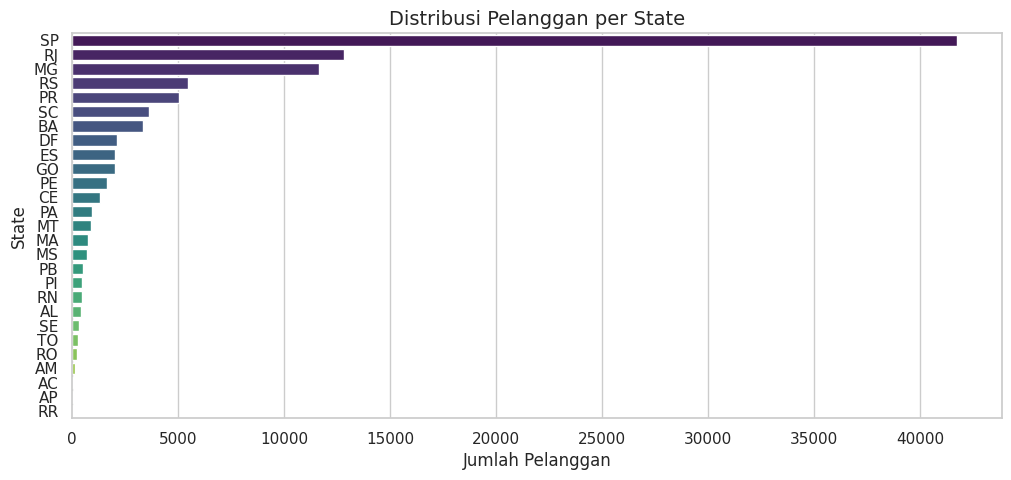

In [11]:
# =====================================================
# EKSPLORASI DATASET CUSTOMERS
# =====================================================

customers_df = clean_data['customers']

print("=" * 60)
print("EKSPLORASI DATASET CUSTOMERS")
print("=" * 60)

# Distribusi pelanggan per kota (top 10)
top_cities = customers_df['customer_city'].value_counts().head(10)
print("\n Top 10 Kota dengan Pelanggan Terbanyak:")
print(top_cities)

# Distribusi pelanggan per state (top 10)
top_states = customers_df['customer_state'].value_counts().head(10)
print("\n Top 10 State dengan Pelanggan Terbanyak:")
print(top_states)

# Visualisasi distribusi pelanggan per state
plt.figure(figsize=(12, 5))
sns.countplot(
    y='customer_state',
    data=customers_df,
    order=customers_df['customer_state'].value_counts().index,
    palette='viridis'
)
plt.title('Distribusi Pelanggan per State', fontsize=14)
plt.xlabel('Jumlah Pelanggan')
plt.ylabel('State')
plt.show()

EKSPLORASI DATASET SELLERS

📍 Top 10 Kota dengan Penjual Terbanyak:
seller_city
sao paulo         694
curitiba          127
rio de janeiro     96
belo horizonte     68
ribeirao preto     52
guarulhos          50
ibitinga           49
santo andre        45
campinas           41
maringa            40
Name: count, dtype: int64

📍 Top 10 State dengan Penjual Terbanyak:
seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
Name: count, dtype: int64


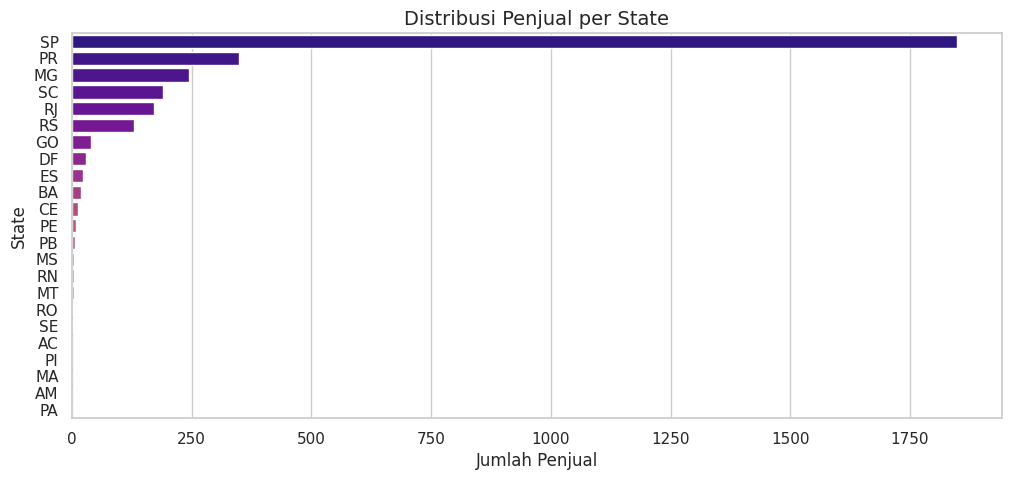

In [12]:
# =====================================================
# EKSPLORASI DATASET SELLERS
# =====================================================

sellers_df = clean_data['sellers']

print("=" * 60)
print("EKSPLORASI DATASET SELLERS")
print("=" * 60)

# Distribusi penjual per kota (top 10)
top_seller_cities = sellers_df['seller_city'].value_counts().head(10)
print("\n📍 Top 10 Kota dengan Penjual Terbanyak:")
print(top_seller_cities)

# Distribusi penjual per state
top_seller_states = sellers_df['seller_state'].value_counts().head(10)
print("\n📍 Top 10 State dengan Penjual Terbanyak:")
print(top_seller_states)

# Visualisasi
plt.figure(figsize=(12, 5))
sns.countplot(
    y='seller_state',
    data=sellers_df,
    order=sellers_df['seller_state'].value_counts().index,
    palette='plasma'
)
plt.title('Distribusi Penjual per State', fontsize=14)
plt.xlabel('Jumlah Penjual')
plt.ylabel('State')
plt.show()

EKSPLORASI DATASET PRODUCTS

📦 Top 10 Kategori Produk Terbanyak:
product_category_name_english
bed_bath_table           3025
sports_leisure           2867
furniture_decor          2657
health_beauty            2444
housewares               2335
auto                     1900
computers_accessories    1639
toys                     1411
watches_gifts            1329
telephony                1134
Name: count, dtype: int64


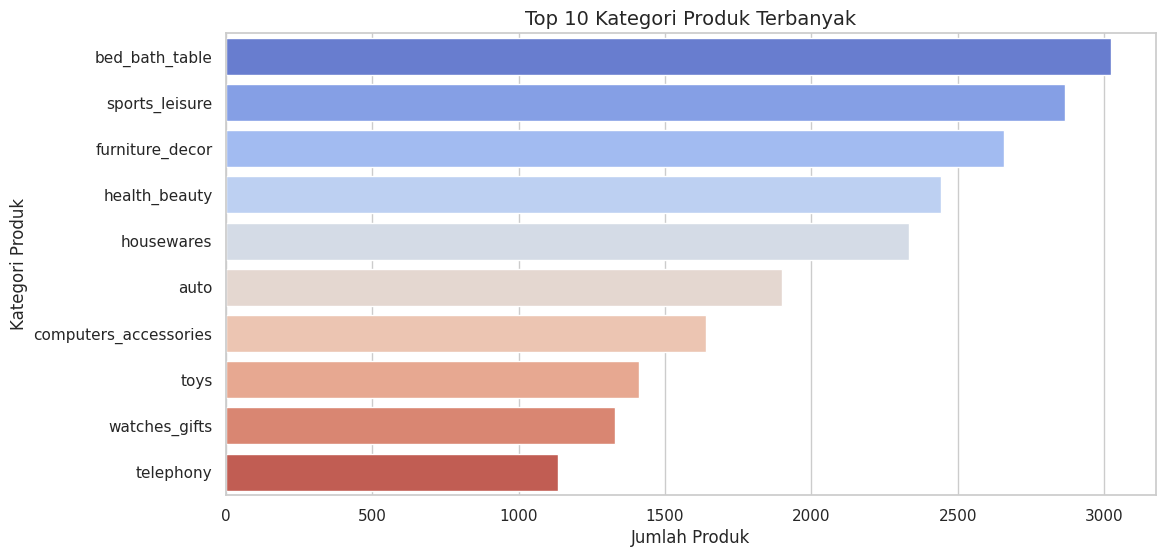

In [13]:
# =====================================================
# EKSPLORASI DATASET PRODUCTS & KATEGORI
# =====================================================

products_df = clean_data['products']
category_translation_df = clean_data['product_category_name_translation']

# Gabungkan dengan translasi kategori
products_with_cat = products_df.merge(
    category_translation_df,
    on='product_category_name',
    how='left'
)

print("=" * 60)
print("EKSPLORASI DATASET PRODUCTS")
print("=" * 60)

# Top 10 kategori produk (dalam bahasa Inggris)
top_categories = products_with_cat['product_category_name_english'].value_counts().head(10)
print("\n Top 10 Kategori Produk Terbanyak:")
print(top_categories)

# Visualisasi
plt.figure(figsize=(12, 6))
sns.countplot(
    y='product_category_name_english',
    data=products_with_cat,
    order=products_with_cat['product_category_name_english'].value_counts().index[:10],
    palette='coolwarm'
)
plt.title('Top 10 Kategori Produk Terbanyak', fontsize=14)
plt.xlabel('Jumlah Produk')
plt.ylabel('Kategori Produk')
plt.show()

EKSPLORASI DATASET ORDERS - TREN WAKTU

📅 Rentang Waktu Pesanan: 2016-09-15 hingga 2018-08-29

📊 Jumlah Pesanan per Bulan (5 teratas):
order_month
2016-09       1
2016-10     265
2016-12       1
2017-01     750
2017-02    1653
Freq: M, dtype: int64


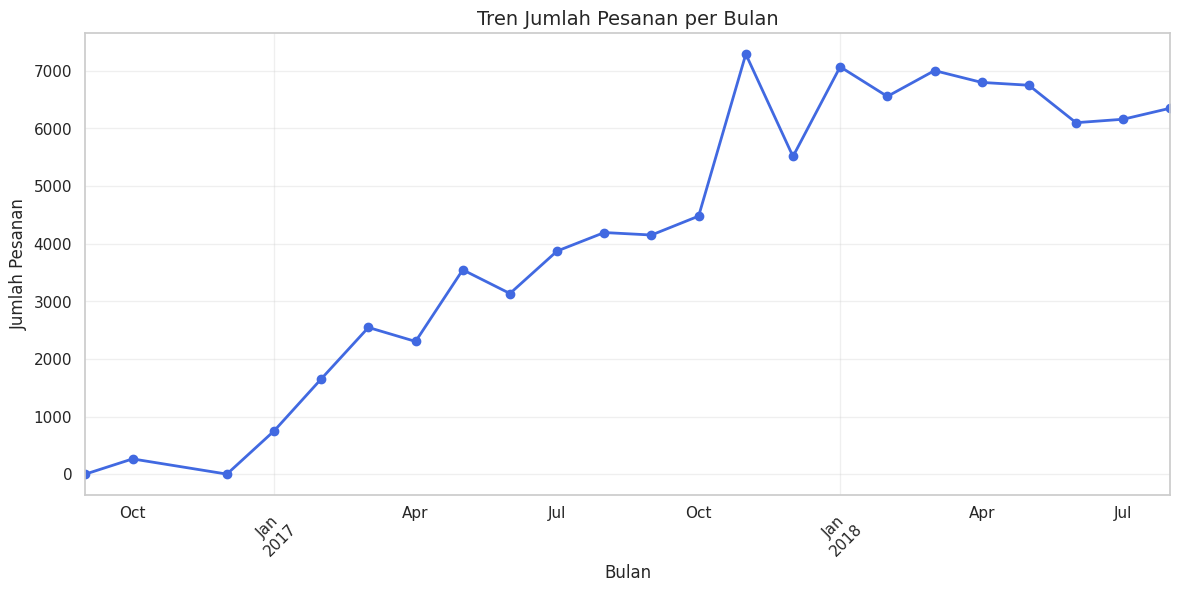

In [14]:
# =====================================================
# EKSPLORASI DATASET ORDERS (TREN WAKTU)
# =====================================================

orders_df = clean_data['orders']

print("=" * 60)
print("EKSPLORASI DATASET ORDERS - TREN WAKTU")
print("=" * 60)

# Rentang waktu data
min_date = orders_df['order_purchase_timestamp'].min()
max_date = orders_df['order_purchase_timestamp'].max()
print(f"\n Rentang Waktu Pesanan: {min_date.date()} hingga {max_date.date()}")

# Buat kolom bulan-tahun
orders_df['order_month'] = orders_df['order_purchase_timestamp'].dt.to_period('M')

# Jumlah pesanan per bulan
monthly_orders = orders_df.groupby('order_month').size()
print("\n Jumlah Pesanan per Bulan (5 teratas):")
print(monthly_orders.head())

# Visualisasi tren pesanan bulanan
plt.figure(figsize=(14, 6))
monthly_orders.plot(kind='line', marker='o', color='royalblue', linewidth=2)
plt.title('Tren Jumlah Pesanan per Bulan', fontsize=14)
plt.xlabel('Bulan')
plt.ylabel('Jumlah Pesanan')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

EKSPLORASI METODE PEMBAYARAN

💳 Distribusi Metode Pembayaran:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
unknown            3
Name: count, dtype: int64


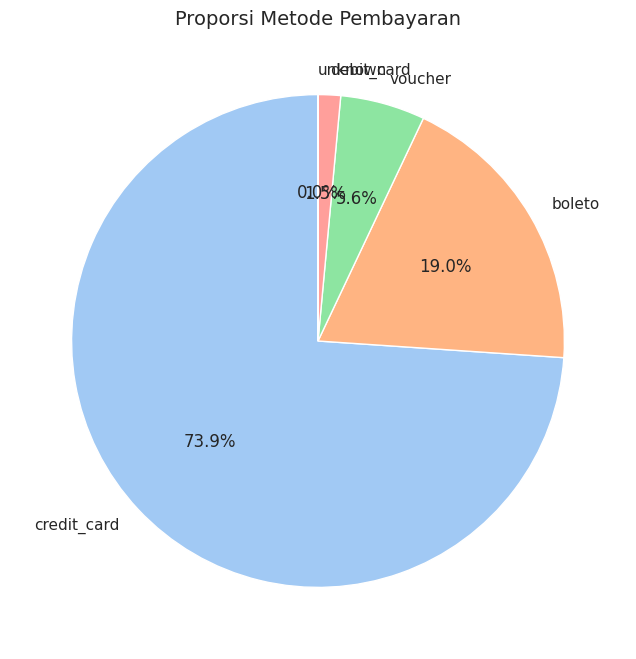


EKSPLORASI SKOR ULASAN

⭐ Distribusi Skor Ulasan (1-5):
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


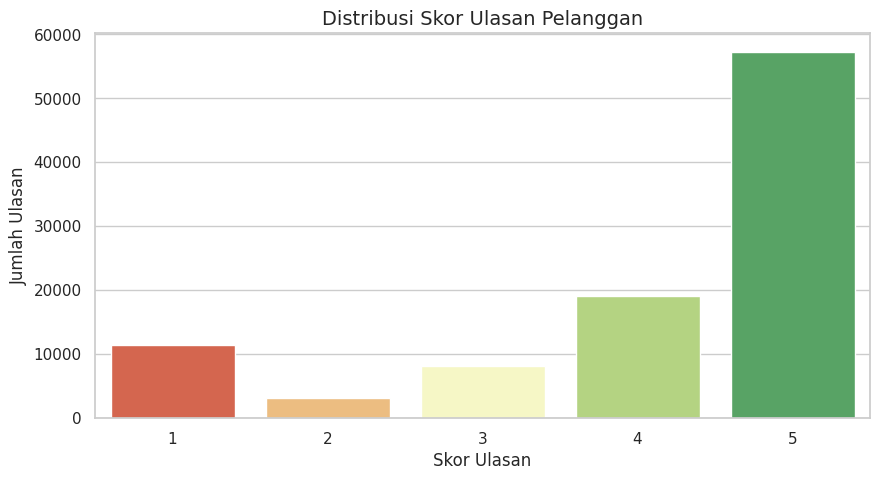

In [15]:
# =====================================================
# EKSPLORASI ORDER PAYMENTS & REVIEWS
# =====================================================

payments_df = clean_data['order_payments']
reviews_df = clean_data['order_reviews']

print("=" * 60)
print("EKSPLORASI METODE PEMBAYARAN")
print("=" * 60)

# Distribusi metode pembayaran
payment_types = payments_df['payment_type'].value_counts()
print("\n Distribusi Metode Pembayaran:")
print(payment_types)

# Visualisasi metode pembayaran
plt.figure(figsize=(8, 8))
plt.pie(
    payment_types.values,
    labels=payment_types.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel'),
    startangle=90
)
plt.title('Proporsi Metode Pembayaran', fontsize=14)
plt.show()

print("\n" + "=" * 60)
print("EKSPLORASI SKOR ULASAN")
print("=" * 60)

# Distribusi skor ulasan
review_scores = reviews_df['review_score'].value_counts().sort_index()
print("\n Distribusi Skor Ulasan (1-5):")
print(review_scores)

# Visualisasi
plt.figure(figsize=(10, 5))
sns.countplot(
    x='review_score',
    data=reviews_df,
    palette='RdYlGn'
)
plt.title('Distribusi Skor Ulasan Pelanggan', fontsize=14)
plt.xlabel('Skor Ulasan')
plt.ylabel('Jumlah Ulasan')
plt.show()

In [16]:
# =====================================================
# MEMBUAT DATAFRAME MASTER
# =====================================================

print("=" * 60)
print("MEMBUAT DATAFRAME MASTER")
print("=" * 60)

# Mulai dari orders (delivered)
master_df = clean_data['orders'].copy()

# 1. Gabung dengan order_items (bisa multiple items per order)
order_items_df = clean_data['order_items']
master_df = master_df.merge(order_items_df, on='order_id', how='inner')

# 2. Gabung dengan products (untuk info kategori)
products_df = clean_data['products']
category_df = clean_data['product_category_name_translation']
products_full = products_df.merge(category_df, on='product_category_name', how='left')
master_df = master_df.merge(products_full, on='product_id', how='left')

# 3. Gabung dengan order_payments
payments_df = clean_data['order_payments']
master_df = master_df.merge(payments_df, on='order_id', how='inner')

# 4. Gabung dengan order_reviews (ambil review_score)
reviews_df = clean_data['order_reviews'][['order_id', 'review_score']]
master_df = master_df.merge(reviews_df, on='order_id', how='left')

# 5. Gabung dengan customers
customers_df = clean_data['customers']
master_df = master_df.merge(customers_df, on='customer_id', how='left')

print(f" DataFrame master berhasil dibuat.")
print(f"   Shape: {master_df.shape}")
print(f"   Jumlah order_id unik: {master_df['order_id'].nunique()}")
print(f"\n Kolom dalam master_df:")
print(master_df.columns.tolist())

# Tampilkan 5 baris pertama
print("\n 5 Baris Pertama DataFrame Master:")
display(master_df.head())

MEMBUAT DATAFRAME MASTER
✅ DataFrame master berhasil dibuat.
   Shape: (115720, 33)
   Jumlah order_id unik: 96477

📋 Kolom dalam master_df:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_month', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'review_score', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

📌 5 Baris Pertama DataFrame Master:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,order_item_id,...,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value,review_score,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,1,...,housewares,1,credit_card,1,18.12,4.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,1,...,housewares,3,voucher,1,2.00,4.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,1,...,housewares,2,voucher,1,18.59,4.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,1,...,perfumery,1,boleto,1,141.46,4.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,1,...,auto,1,credit_card,3,179.12,5.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


### 🔍 Insight dari Exploratory Data Analysis (EDA)

Berdasarkan hasil eksplorasi seluruh dataset, berikut temuan utama yang menjadi dasar untuk menjawab pertanyaan bisnis:

---

#### 1. **Dominasi Wilayah São Paulo (SP) pada Pelanggan dan Penjual**
- **Pelanggan:** 41.746 dari total 99.441 pelanggan (≈42%) berasal dari negara bagian SP. Kota **São Paulo** sendiri menyumbang 15.540 pelanggan, jauh di atas kota lainnya.
- **Penjual:** 1.849 dari 3.095 penjual (≈60%) juga berada di SP, dengan 694 penjual terkonsentrasi di kota São Paulo.
- **Implikasi:** Konsentrasi pasar di SP sangat tinggi. Strategi logistik, inventaris gudang, dan kampanye pemasaran sebaiknya diprioritaskan di wilayah ini untuk efisiensi biaya dan peningkatan layanan.

---

#### 2. **Kategori Produk Terbanyak: Kebutuhan Rumah Tangga & Gaya Hidup**
- **Top 3 kategori** dengan jumlah produk terbanyak:
  1. `bed_bath_table` (3.025 produk) – perlengkapan tempat tidur, kamar mandi, meja.
  2. `sports_leisure` (2.867 produk) – olahraga dan rekreasi.
  3. `furniture_decor` (2.657 produk) – furnitur dan dekorasi.
- Kategori seperti `health_beauty` (kesehatan & kecantikan) dan `housewares` (peralatan rumah tangga) juga memiliki jumlah produk signifikan.
- **Implikasi:** Permintaan pasar didominasi oleh produk rumah tangga dan perawatan diri. Manajemen stok dan promosi dapat difokuskan pada kategori-kategori ini.

---

#### 3. **Periode Data & Pertumbuhan Pesanan Awal**
- Rentang waktu data: **15 September 2016 – 29 Agustus 2018** (≈2 tahun).
- Bulan-bulan awal (2016) memiliki jumlah pesanan sangat sedikit (hanya 1–265 pesanan), kemungkinan karena platform masih baru atau data belum lengkap.
- Mulai **Januari 2017**, volume pesanan meningkat stabil (750 pesanan) dan terus bertumbuh hingga >1.600 di Februari 2017.
- **Implikasi:** Analisis tren sebaiknya difokuskan mulai **2017** ke atas untuk menghindari bias data awal yang terlalu kecil.

---

#### 4. **Metode Pembayaran: Kartu Kredit Mendominasi**
- **Credit Card:** 76.795 transaksi (≈74%).
- **Boleto (voucher bank):** 19.784 transaksi (≈19%).
- **Voucher & Debit Card:** masing-masing <6%.
- Terdapat 3 transaksi dengan tipe `unknown` – dapat diabaikan.
- **Implikasi:** Sebagian besar pelanggan nyaman menggunakan kartu kredit. Kerja sama dengan penyedia kartu kredit untuk program cicilan atau promo dapat meningkatkan nilai transaksi.

---

#### 5. **Tingkat Kepuasan Pelanggan Cenderung Tinggi**
- **Skor 5:** 57.328 ulasan (≈57%)
- **Skor 4:** 19.142 ulasan (≈19%)
- **Skor 1–3:** sekitar 24% sisanya.
- **Total skor 4 & 5 mencapai 76%**, menandakan mayoritas pelanggan puas.
- **Implikasi:** Perusahaan memiliki basis pelanggan yang cukup loyal. Namun perlu investigasi lebih lanjut terhadap 11.424 ulasan skor 1 (pengalaman buruk) untuk perbaikan layanan.

---

#### 6. **DataFrame Master Siap untuk Analisis Lanjutan**
- **Shape:** 115.720 baris × 33 kolom.
- **Jumlah order_id unik:** 96.477 (hampir sama dengan total pesanan delivered).
- Semua informasi penting dari 9 dataset telah tergabung dalam satu tabel, mencakup:
  - Data transaksi (orders, items, payments)
  - Data produk & kategori (dalam bahasa Inggris)
  - Data pelanggan (kota, state)
  - Skor ulasan
- **Implikasi:** DataFrame master ini memungkinkan analisis multidimensi tanpa perlu join berulang, mempercepat proses visualisasi dan perhitungan metrik bisnis.

## Visualization & Explanatory Analysis

Pada bagian ini, kita akan membuat visualisasi data yang efektif untuk menjawab setiap pertanyaan bisnis yang telah ditetapkan di awal. Setiap visualisasi akan disertai dengan penjelasan insight yang dapat ditindaklanjuti.

### Pertanyaan 1:

Bagaimana tren volume penjualan dan total pendapatan perusahaan secara bulanan?

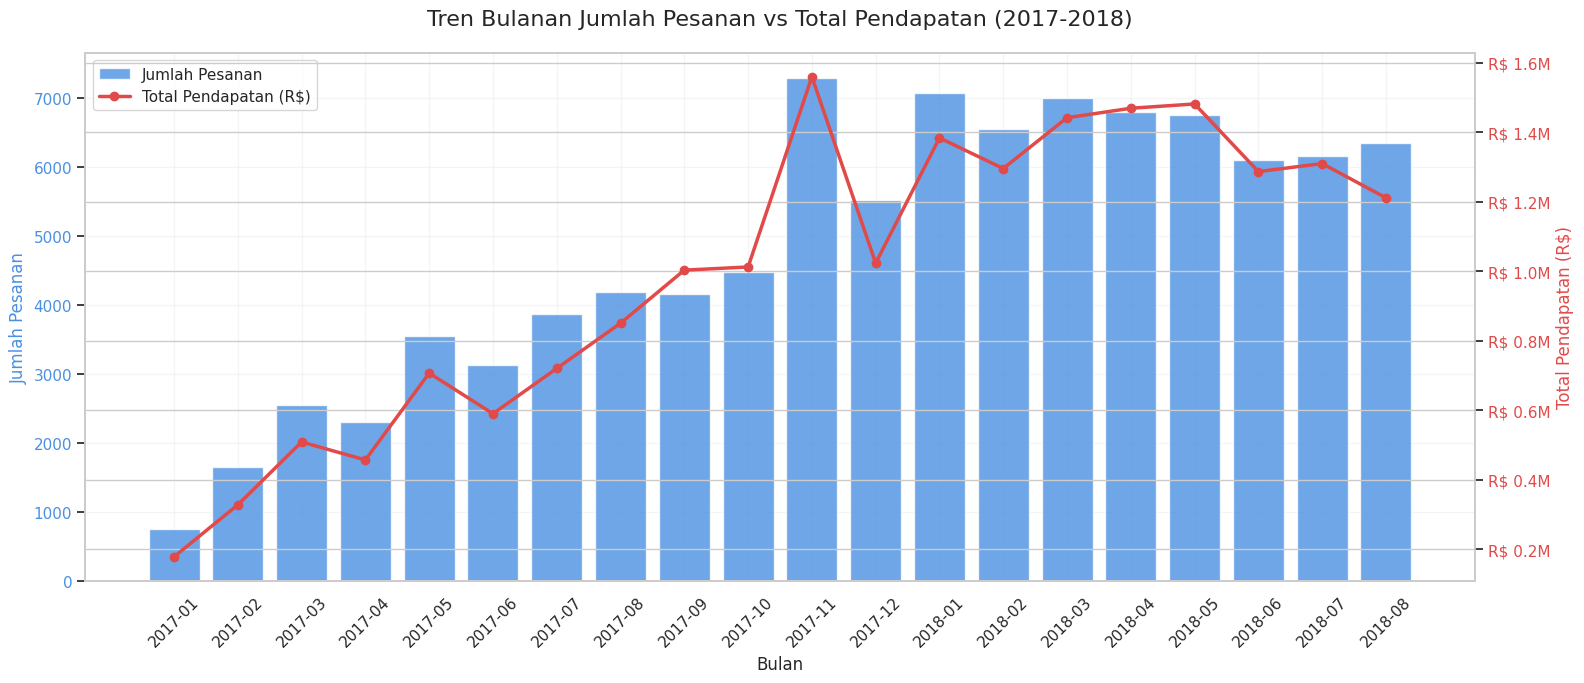


📊 Ringkasan Data Bulanan:
Rata-rata pesanan per bulan: 4811
Rata-rata pendapatan per bulan: R$ 990,986.98
Bulan dengan pesanan terbanyak: 2017-11 (7289 pesanan)
Bulan dengan pendapatan tertinggi: 2017-11 (R$ 1,559,739.87)


In [17]:
# =====================================================
# PERTANYAAN 1: Tren Volume Penjualan & Pendapatan Bulanan
# =====================================================

# Agregasi data per bulan
monthly_data = master_df.groupby('order_month').agg({
    'order_id': 'nunique',      # Jumlah pesanan unik per bulan
    'payment_value': 'sum'      # Total pendapatan per bulan
}).reset_index()
monthly_data['order_month'] = monthly_data['order_month'].astype(str)

# Filter bulan dengan data terlalu sedikit di awal (opsional: mulai 2017)
monthly_data = monthly_data[monthly_data['order_month'] >= '2017-01']

# Buat visualisasi dual-axis
fig, ax1 = plt.subplots(figsize=(16, 7))

# Bar chart untuk jumlah pesanan
bars = ax1.bar(monthly_data['order_month'], monthly_data['order_id'],
               color='#4A90E2', alpha=0.8, label='Jumlah Pesanan')
ax1.set_xlabel('Bulan', fontsize=12)
ax1.set_ylabel('Jumlah Pesanan', color='#4A90E2', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#4A90E2')
ax1.tick_params(axis='x', rotation=45)

# Line chart untuk total pendapatan pada sumbu y kedua
ax2 = ax1.twinx()
line = ax2.plot(monthly_data['order_month'], monthly_data['payment_value'],
                color='#E24A4A', marker='o', linewidth=2.5, markersize=6,
                label='Total Pendapatan (R$)')
ax2.set_ylabel('Total Pendapatan (R$)', color='#E24A4A', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#E24A4A')

# Format sumbu y pendapatan ke dalam juta
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'R$ {x/1e6:.1f}M'))

# Judul dan grid
plt.title('Tren Bulanan Jumlah Pesanan vs Total Pendapatan (2017-2018)', fontsize=16, pad=20)
ax1.grid(True, alpha=0.2)

# Gabungkan legend
lines_labels = [ax1.get_legend_handles_labels(), ax2.get_legend_handles_labels()]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
ax1.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.show()

# Tampilkan data 5 bulan teratas dan terbawah untuk konteks
print("\n Ringkasan Data Bulanan:")
print(f"Rata-rata pesanan per bulan: {monthly_data['order_id'].mean():.0f}")
print(f"Rata-rata pendapatan per bulan: R$ {monthly_data['payment_value'].mean():,.2f}")
print(f"Bulan dengan pesanan terbanyak: {monthly_data.loc[monthly_data['order_id'].idxmax(), 'order_month']} ({monthly_data['order_id'].max()} pesanan)")
print(f"Bulan dengan pendapatan tertinggi: {monthly_data.loc[monthly_data['payment_value'].idxmax(), 'order_month']} (R$ {monthly_data['payment_value'].max():,.2f})")

### Pertanyaan 2:

Kategori produk apa yang paling laris dan memberikan kontribusi pendapatan terbesar?

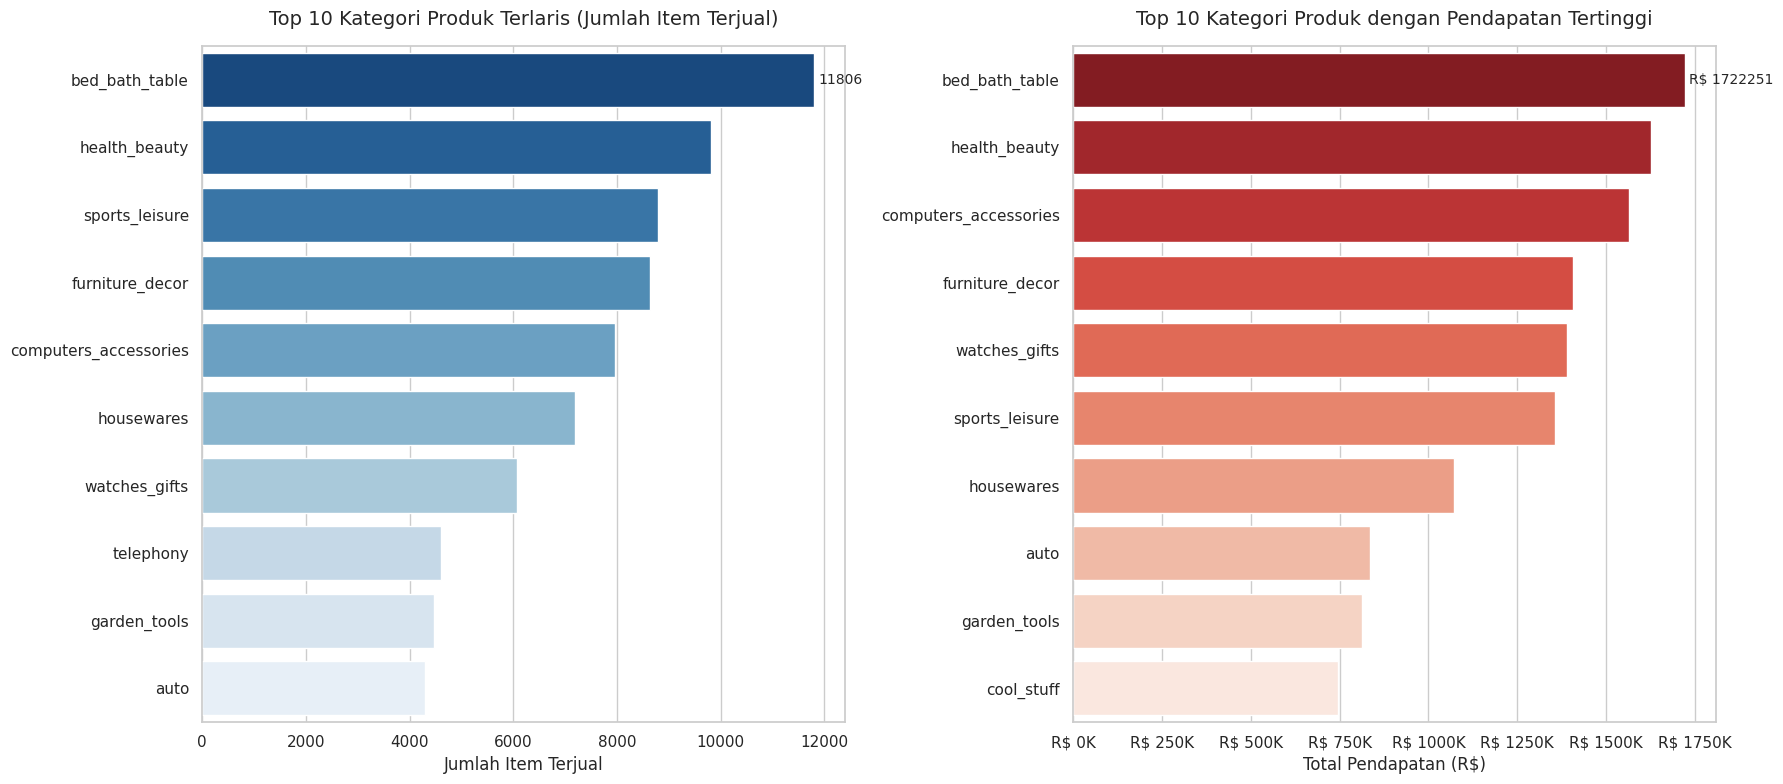


📊 Perbandingan Ranking Kategori:


,kategori,jumlah_terjual,total_pendapatan
0,auto,4302.0,835782.91
1,bed_bath_table,11806.0,1722250.80
2,computers_accessories,7963.0,1563315.62
3,cool_stuff,0.0,746763.39
4,furniture_decor,8643.0,1408110.04
5,garden_tools,4480.0,813055.77
6,health_beauty,9813.0,1625923.50
7,housewares,7196.0,1072820.85
8,sports_leisure,8791.0,1357249.46
9,telephony,4607.0,0.00


In [18]:
# =====================================================
# PERTANYAAN 2: Kategori Produk Terlaris & Pendapatan Tertinggi
# =====================================================

# Agregasi per kategori
category_stats = master_df.groupby('product_category_name_english').agg({
    'order_id': 'count',        # Jumlah item terjual
    'payment_value': 'sum'      # Total pendapatan
}).reset_index()
category_stats.columns = ['kategori', 'jumlah_terjual', 'total_pendapatan']

# Top 10 berdasarkan jumlah terjual
top10_qty = category_stats.nlargest(10, 'jumlah_terjual')
# Top 10 berdasarkan pendapatan
top10_rev = category_stats.nlargest(10, 'total_pendapatan')

# Visualisasi side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Plot 1: Jumlah Terjual
sns.barplot(
    y='kategori',
    x='jumlah_terjual',
    data=top10_qty,
    palette='Blues_r',
    ax=ax1
)
ax1.set_title('Top 10 Kategori Produk Terlaris (Jumlah Item Terjual)', fontsize=14, pad=15)
ax1.set_xlabel('Jumlah Item Terjual', fontsize=12)
ax1.set_ylabel('')
ax1.bar_label(ax1.containers[0], fmt='%.0f', padding=3, fontsize=10)

# Plot 2: Total Pendapatan
sns.barplot(
    y='kategori',
    x='total_pendapatan',
    data=top10_rev,
    palette='Reds_r',
    ax=ax2
)
ax2.set_title('Top 10 Kategori Produk dengan Pendapatan Tertinggi', fontsize=14, pad=15)
ax2.set_xlabel('Total Pendapatan (R$)', fontsize=12)
ax2.set_ylabel('')
ax2.bar_label(ax2.containers[0], fmt='R$ %.0f', padding=3, fontsize=10)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'R$ {x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

# Tampilkan perbandingan ranking
print("\n Perbandingan Ranking Kategori:")
comparison = top10_qty[['kategori', 'jumlah_terjual']].merge(
    top10_rev[['kategori', 'total_pendapatan']],
    on='kategori',
    how='outer'
).fillna(0)
display(comparison)

### Pertanyaan 3:

Bagaimana tingkat kepuasan pelanggan berdasarkan skor ulasan? Apakah ada hubungan dengan waktu pengiriman?

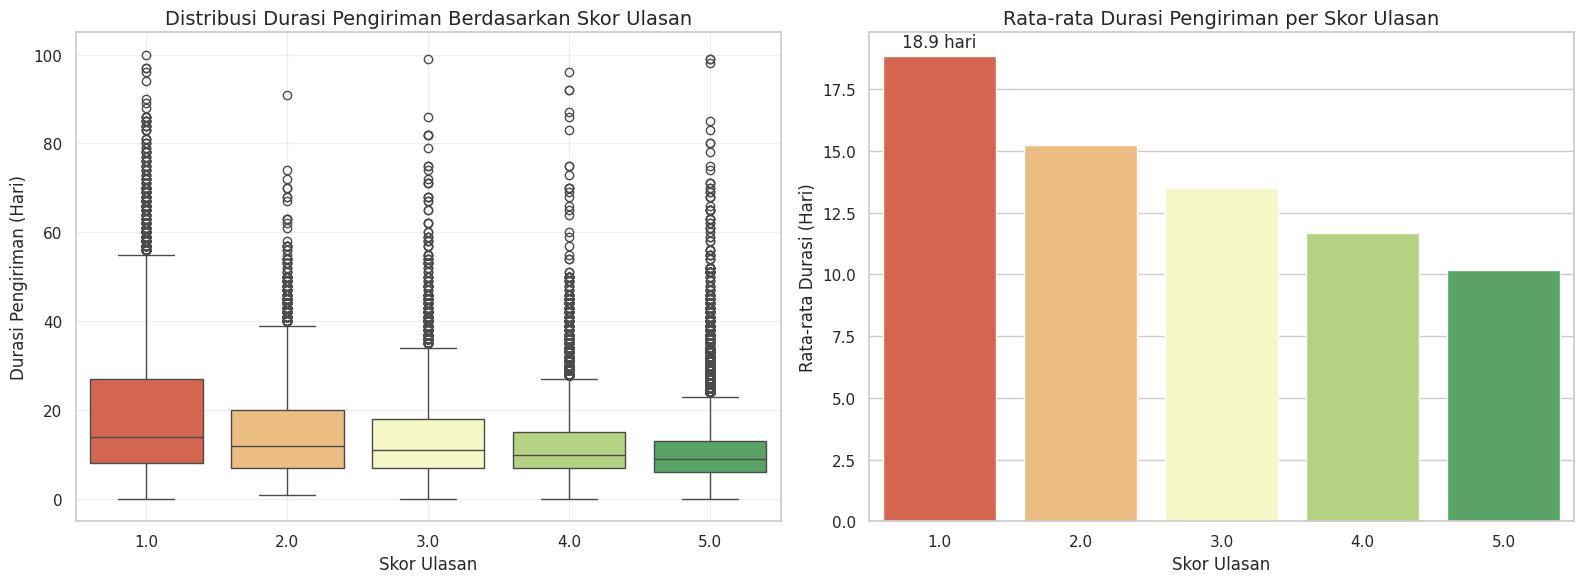


📈 Korelasi Pearson antara durasi pengiriman dan skor ulasan: -0.317

📊 Rata-rata durasi pengiriman per skor:


,review_score,delivery_days
0,1.0,18.865536
1,2.0,15.236714
2,3.0,13.488336
3,4.0,11.660898
4,5.0,10.169216


In [19]:
# =====================================================
# PERTANYAAN 3: Skor Ulasan & Hubungan dengan Durasi Pengiriman
# =====================================================

# Hitung durasi pengiriman (hari)
master_df['delivery_days'] = (master_df['order_delivered_customer_date'] -
                               master_df['order_purchase_timestamp']).dt.days

# Filter outlier (durasi > 100 hari)
delivery_review_df = master_df[master_df['delivery_days'] <= 100].copy()

# Hitung rata-rata durasi per skor
avg_delivery = delivery_review_df.groupby('review_score')['delivery_days'].mean().reset_index()

# Visualisasi: Boxplot distribusi durasi per skor
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
sns.boxplot(
    x='review_score',
    y='delivery_days',
    data=delivery_review_df,
    palette='RdYlGn',
    ax=ax1
)
ax1.set_title('Distribusi Durasi Pengiriman Berdasarkan Skor Ulasan', fontsize=14)
ax1.set_xlabel('Skor Ulasan')
ax1.set_ylabel('Durasi Pengiriman (Hari)')
ax1.grid(True, alpha=0.3)

# Bar chart rata-rata durasi
sns.barplot(
    x='review_score',
    y='delivery_days',
    data=avg_delivery,
    palette='RdYlGn',
    ax=ax2
)
ax2.set_title('Rata-rata Durasi Pengiriman per Skor Ulasan', fontsize=14)
ax2.set_xlabel('Skor Ulasan')
ax2.set_ylabel('Rata-rata Durasi (Hari)')
ax2.bar_label(ax2.containers[0], fmt='%.1f hari', padding=3)

plt.tight_layout()
plt.show()

# Hitung korelasi
corr = delivery_review_df[['delivery_days', 'review_score']].corr().iloc[0, 1]
print(f"\n Korelasi Pearson antara durasi pengiriman dan skor ulasan: {corr:.3f}")
print("\n Rata-rata durasi pengiriman per skor:")
display(avg_delivery)

### Pertanyaan 4:

Bagaimana pola pembayaran yang digunakan pelanggan? Apakah ada perbedaan nilai transaksi antar metode?

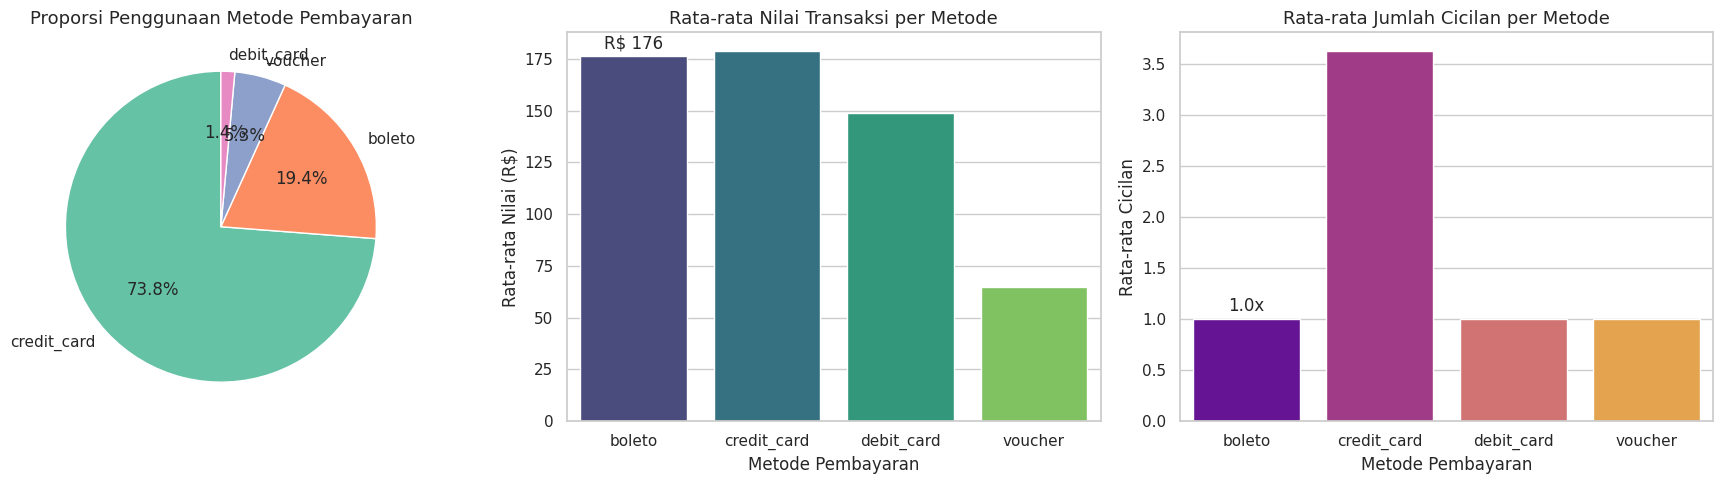


📊 Detail Statistik Metode Pembayaran:


,metode,rata_nilai,rata_cicilan,jumlah_pesanan
0,boleto,176.234307,1.000000,19191
1,credit_card,178.848820,3.630406,74304
2,debit_card,149.027966,1.000000,1485
3,voucher,64.621594,1.000000,3679


In [20]:
# =====================================================
# PERTANYAAN 4: Pola Pembayaran & Nilai Transaksi
# =====================================================

# Agregasi per metode pembayaran
payment_stats = master_df.groupby('payment_type').agg({
    'payment_value': 'mean',
    'payment_installments': 'mean',
    'order_id': 'nunique'
}).reset_index()
payment_stats.columns = ['metode', 'rata_nilai', 'rata_cicilan', 'jumlah_pesanan']

# Filter metode yang relevan (buang 'unknown' jika ada)
payment_stats = payment_stats[payment_stats['metode'] != 'unknown']

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Proporsi Penggunaan Metode
metode_counts = master_df['payment_type'].value_counts()
axes[0].pie(
    metode_counts.values,
    labels=metode_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('Set2'),
    startangle=90
)
axes[0].set_title('Proporsi Penggunaan Metode Pembayaran', fontsize=13)

# 2. Rata-rata Nilai Transaksi per Metode
sns.barplot(
    x='metode',
    y='rata_nilai',
    data=payment_stats,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title('Rata-rata Nilai Transaksi per Metode', fontsize=13)
axes[1].set_xlabel('Metode Pembayaran')
axes[1].set_ylabel('Rata-rata Nilai (R$)')
axes[1].bar_label(axes[1].containers[0], fmt='R$ %.0f', padding=3)

# 3. Rata-rata Jumlah Cicilan per Metode
sns.barplot(
    x='metode',
    y='rata_cicilan',
    data=payment_stats,
    palette='plasma',
    ax=axes[2]
)
axes[2].set_title('Rata-rata Jumlah Cicilan per Metode', fontsize=13)
axes[2].set_xlabel('Metode Pembayaran')
axes[2].set_ylabel('Rata-rata Cicilan')
axes[2].bar_label(axes[2].containers[0], fmt='%.1fx', padding=3)

plt.tight_layout()
plt.show()

print("\n Detail Statistik Metode Pembayaran:")
display(payment_stats)

### Pertanyaan 5:

Bagaimana segmentasi pelanggan berdasarkan perilaku pembelian?


📊 Ringkasan Segmen Pelanggan:


,jumlah,rata_recency,rata_freq,rata_monetary,persentase
segment,,,,,
Regular,63685,272.6,1.0,197.3,68.2
New Customers,8861,94.5,1.0,64.8,9.5
Best Customers,7831,82.2,1.2,433.8,8.4
Lost / At Risk,7383,414.3,1.1,403.8,7.9
Loyal Customers,5597,56.3,1.0,64.9,6.0


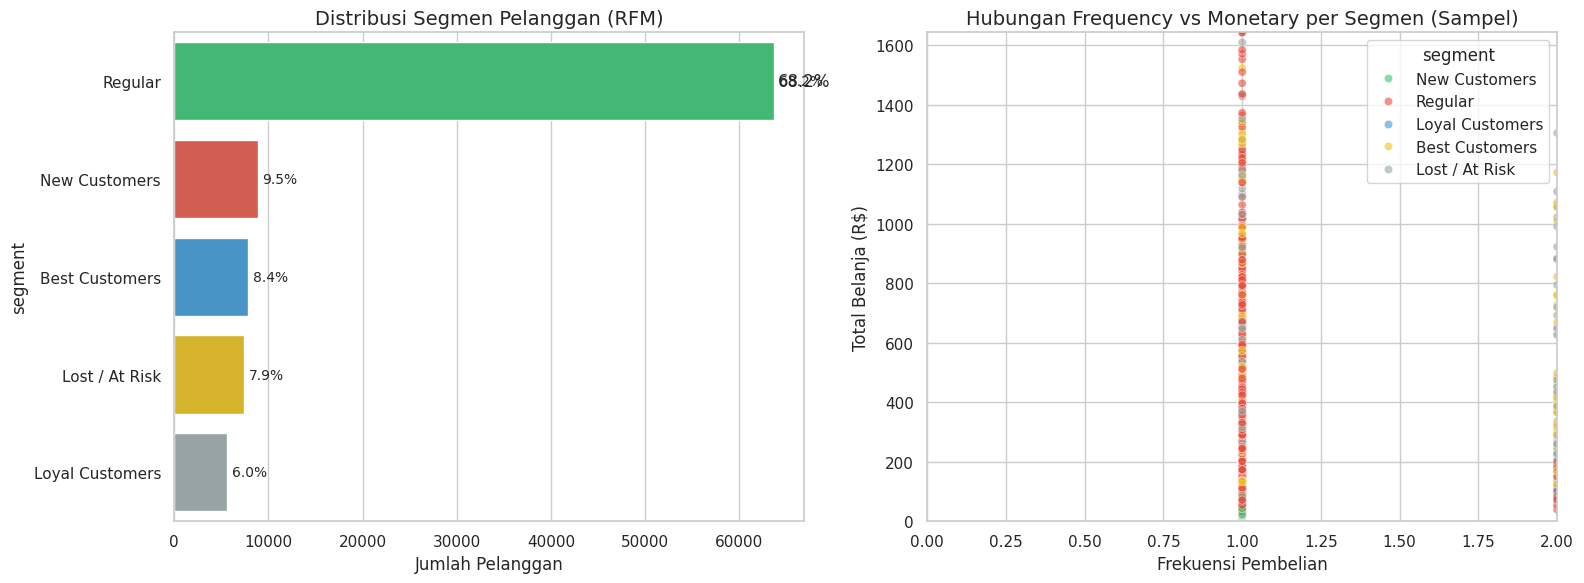

In [21]:
# =====================================================
# PERTANYAAN 5: Segmentasi Pelanggan dengan RFM
# =====================================================

# Jalankan RFM analysis
from datetime import timedelta

reference_date = master_df['order_purchase_timestamp'].max() + timedelta(days=1)

rfm_df = master_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (reference_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum'
}).reset_index()
rfm_df.columns = ['customer_id', 'recency', 'frequency', 'monetary']

# Skoring kuartil
rfm_df['R_score'] = pd.qcut(rfm_df['recency'], 4, labels=[4, 3, 2, 1])
rfm_df['F_score'] = pd.qcut(rfm_df['frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm_df['M_score'] = pd.qcut(rfm_df['monetary'], 4, labels=[1, 2, 3, 4])

rfm_df['RFM_score'] = rfm_df['R_score'].astype(str) + rfm_df['F_score'].astype(str) + rfm_df['M_score'].astype(str)

# Fungsi segmentasi
def segment_customer(row):
    if row['RFM_score'] in ['444', '443', '434', '344', '433']:
        return 'Best Customers'
    elif row['RFM_score'] in ['144', '143', '134', '133', '244']:
        return 'Lost / At Risk'
    elif row['RFM_score'] in ['411', '412', '421', '422', '311', '312']:
        return 'New Customers'
    elif row['RFM_score'] in ['441', '442', '432', '431']:
        return 'Loyal Customers'
    else:
        return 'Regular'

rfm_df['segment'] = rfm_df.apply(segment_customer, axis=1)

# Ringkasan segmen
segment_summary = rfm_df.groupby('segment').agg({
    'customer_id': 'count',
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'mean'
}).round(1)
segment_summary.columns = ['jumlah', 'rata_recency', 'rata_freq', 'rata_monetary']
segment_summary['persentase'] = (segment_summary['jumlah'] / segment_summary['jumlah'].sum() * 100).round(1)
segment_summary = segment_summary.sort_values('jumlah', ascending=False)

# Tampilkan ringkasan
print("\n📊 Ringkasan Segmen Pelanggan:")
display(segment_summary)

# Visualisasi dengan penanganan error pada bar_label
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Distribusi Segmen
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f1c40f', '#95a5a6']
bars = sns.barplot(
    y=segment_summary.index,
    x='jumlah',
    data=segment_summary,
    palette=colors,
    ax=ax1
)
ax1.set_title('Distribusi Segmen Pelanggan (RFM)', fontsize=14)
ax1.set_xlabel('Jumlah Pelanggan')

# Tambahkan label persentase secara manual
try:
    ax1.bar_label(ax1.containers[0], labels=segment_summary['persentase'].astype(str) + '%', padding=3)
except (AttributeError, IndexError, TypeError):
    # Fallback: gunakan text manual
    for i, (value, pct) in enumerate(zip(segment_summary['jumlah'], segment_summary['persentase'])):
        ax1.text(value + 500, i, f'{pct}%', va='center', fontsize=10)

# 2. Scatter plot Monetary vs Frequency dengan warna segmen
rfm_sample = rfm_df.sample(min(5000, len(rfm_df)), random_state=42)  # Sampel untuk visualisasi
sns.scatterplot(
    data=rfm_sample,
    x='frequency',
    y='monetary',
    hue='segment',
    palette=colors[:len(rfm_sample['segment'].unique())],
    alpha=0.6,
    ax=ax2
)
ax2.set_title('Hubungan Frequency vs Monetary per Segmen (Sampel)', fontsize=14)
ax2.set_xlabel('Frekuensi Pembelian')
ax2.set_ylabel('Total Belanja (R$)')
ax2.set_xlim(0, rfm_sample['frequency'].quantile(0.99))  # Batasi outlier
ax2.set_ylim(0, rfm_sample['monetary'].quantile(0.99))

plt.tight_layout()
plt.show()

**Insight:**

## Pertanyaan 1: Tren Volume Penjualan & Pendapatan Bulanan

Berdasarkan visualisasi tren bulanan, diperoleh beberapa temuan penting:

- **Rata-rata Bulanan:** Setiap bulan, platform mencatat sekitar **4.811 pesanan** dengan pendapatan rata-rata **990.987**. Angka ini menunjukkan skala bisnis yang cukup stabil.
- **Puncak Tertinggi di November 2017:** Bulan **November 2017** menjadi bulan terbaik dengan **7.289 pesanan** dan pendapatan **R$ 1,56 juta**. Lonjakan ini kemungkinan besar dipicu oleh **promo akhir tahun (Black Friday/Natal)**.
- **Implikasi Strategis:** Persiapkan stok dan logistik lebih awal untuk periode **Oktober–Desember**. Manfaatkan bulan-bulan sepi untuk program loyalitas atau diskon terbatas guna menjaga kestabilan pendapatan.

---

## 📌 Pertanyaan 2: Kategori Produk Terlaris & Pendapatan Tertinggi

Dari perbandingan volume penjualan dan pendapatan per kategori, terlihat pola menarik:

| Kategori | Jumlah Terjual | Total Pendapatan (R$) | Catatan |
|----------|---------------|----------------------|---------|
| **bed_bath_table** | 11.806 | 1.722.250 | Juara volume & pendapatan |
| **health_beauty** | 9.813 | 1.625.923 | Volume tinggi, margin baik |
| **computers_accessories** | 7.963 | 1.563.315 | Harga per unit tinggi |
| **watches_gifts** | 6.077 | 1.388.699 | Kategori hadiah bernilai tinggi |
| **sports_leisure** | 8.791 | 1.357.249 | Volume tinggi, pendapatan solid |

**Temuan Utama:**
1. **`bed_bath_table` (Perlengkapan Rumah Tangga)** adalah **kategori andalan** – menguasai volume tertinggi sekaligus pendapatan terbesar.
2. **`computers_accessories` & `watches_gifts`** memiliki pendapatan besar meski volume lebih rendah → **harga per unit relatif mahal**, margin potensial tinggi.
3. **Anomali Data:** Kategori **`telephony`** mencatat 4.607 item terjual namun **total pendapatan 0** (perlu investigasi). Kategori **`cool_stuff`** memiliki pendapatan R$ 746 ribu tanpa data jumlah terjual.

**Rekomendasi Bisnis:** Fokuskan inventaris pada kategori unggulan, optimalkan tampilan produk bernilai tinggi, dan periksa integritas data anomali.

---

## 📌 Pertanyaan 3: Kepuasan Pelanggan & Durasi Pengiriman

Analisis hubungan antara skor ulasan dan lama pengiriman:

| Skor Ulasan | Rata-rata Durasi Pengiriman (hari) |
|-------------|-----------------------------------|
| 1 | 18,9 |
| 2 | 15,2 |
| 3 | 13,5 |
| 4 | 11,7 |
| 5 | 10,2 |

- **Korelasi Negatif Signifikan (r = -0,317):** Semakin lama barang sampai, semakin rendah skor yang diberikan. Penurunan skor terjadi secara **gradual dan konsisten**.
- **Perbedaan Mencolok:** Pelanggan skor 5 menerima pesanan rata-rata dalam **10 hari**, sedangkan skor 1 menunggu hingga **19 hari** – hampir **dua kali lebih lama**.
- **Interpretasi:** Kecepatan pengiriman adalah **faktor penentu utama kepuasan pelanggan**.

**Rekomendasi Bisnis:** Tetapkan SLA internal (80% pesanan ≤10 hari), identifikasi penjual dengan waktu kirim >15 hari, dan berikan kompensasi jika terjadi keterlambatan.

---

## 📌 Pertanyaan 4: Pola Pembayaran & Nilai Transaksi

Statistik metode pembayaran:

| Metode | Rata-rata Nilai (R$) | Rata-rata Cicilan | Jumlah Pesanan |
|--------|---------------------|-------------------|----------------|
| **credit_card** | 178,85 | 3,6 | 74.304 |
| **boleto** | 176,23 | 1,0 | 19.191 |
| **debit_card** | 149,03 | 1,0 | 1.485 |
| **voucher** | 64,62 | 1,0 | 3.679 |

**Temuan Penting:**
1. **Kartu Kredit Mendominasi (≈75%)** dengan nilai transaksi tinggi dan cicilan rata-rata 3,6 kali.
2. **Boleto** digunakan pada 19% transaksi dengan nilai hampir setara kartu kredit, cocok untuk pelanggan non-kartu kredit.
3. **Debit Card & Voucher** volume kecil; voucher umumnya untuk pembelian bernilai rendah.

**Rekomendasi Bisnis:** Tampilkan kalkulator cicilan di halaman produk, optimalkan proses Boleto, dan dorong penggunaan debit card dengan promo kecil.

---

## 📌 Pertanyaan 5: Segmentasi Pelanggan (RFM Analysis)

Analisis RFM membagi **93.357 pelanggan unik** ke dalam 5 segmen:

| Segmen | Jumlah | % | Recency (hari) | Freq | Monetary (R$) | Interpretasi |
|--------|--------|---|----------------|------|---------------|--------------|
| **Regular** | 63.685 | 68,2% | 273 | 1,0 | 197 | Pembeli satu kali, sudah lama tidak kembali |
| **New Customers** | 8.861 | 9,5% | 95 | 1,0 | 65 | Pembeli baru, nilai belanja rendah |
| **Best Customers** | 7.831 | 8,4% | 82 | 1,2 | 434 | Baru beli, frekuensi & nilai tinggi |
| **Lost / At Risk** | 7.383 | 7,9% | 414 | 1,1 | 404 | Sudah >1 tahun tidak beli, nilai historis tinggi |
| **Loyal Customers** | 5.597 | 6,0% | 56 | 1,0 | 65 | Sering beli, nilai kecil, recency rendah |

**Rekomendasi Strategis per Segmen:**
- **Best Customers (8,4%):** Berikan program VIP, akses eksklusif, dan apresiasi personal.
- **Loyal Customers (6,0%):** Kirim rekomendasi produk berdasarkan riwayat belanja, tawarkan *upsell*.
- **New Customers (9,5%):** Email selamat datang + diskon pembelian kedua untuk mendorong *repeat order*.
- **Lost / At Risk (7,9%):** Tawarkan "We Miss You" discount atau survey alasan tidak kembali.
- **Regular (68,2%):** Kampanye re-engagement massal, rekomendasi produk populer, atau program *bundling*.

**Dampak Strategis:** Segmentasi ini memungkinkan alokasi anggaran pemasaran yang lebih efisien – fokus mempertahankan pelanggan bernilai tinggi dan mengaktifkan kembali pelanggan yang hampir hilang.

## Analisis Lanjutan (Opsional)

In [22]:
# =====================================================
# EKSPOR DATA UNTUK DASHBOARD
# =====================================================

# Pilih kolom yang diperlukan untuk dashboard
dashboard_df = master_df[[
    'order_purchase_timestamp',
    'order_status',
    'payment_value',
    'product_category_name_english',
    'customer_city',
    'customer_state',
    'review_score',
    'payment_type',
    'payment_installments'
]].copy()

# Simpan ke CSV
dashboard_df.to_csv('main_data.csv', index=False)

print("✅ File main_data.csv berhasil dibuat.")
print(f"   Shape: {dashboard_df.shape}")
print(f"   Lokasi: {dashboard_df}")

✅ File main_data.csv berhasil dibuat.
   Shape: (115720, 9)
   Lokasi:        order_purchase_timestamp order_status  payment_value  \
0           2017-10-02 10:56:33    delivered          18.12   
1           2017-10-02 10:56:33    delivered           2.00   
2           2017-10-02 10:56:33    delivered          18.59   
3           2018-07-24 20:41:37    delivered         141.46   
4           2018-08-08 08:38:49    delivered         179.12   
...                         ...          ...            ...   
115715      2018-02-06 12:58:58    delivered         195.00   
115716      2017-08-27 14:46:43    delivered         271.01   
115717      2018-01-08 21:28:27    delivered         441.16   
115718      2018-01-08 21:28:27    delivered         441.16   
115719      2018-03-08 20:57:30    delivered          86.86   

       product_category_name_english customer_city customer_state  \
0                         housewares     sao paulo             SP   
1                         housewar

## Conclusion

Berdasarkan hasil analisis data yang telah dilakukan, berikut adalah kesimpulan dan rekomendasi strategis untuk setiap pertanyaan bisnis.

---

##Pertanyaan 1: Tren Volume Penjualan & Pendapatan Bulanan

**Kesimpulan:**
- Bisnis menunjukkan tren pertumbuhan positif sepanjang 2017–2018 dengan rata-rata **4.811 pesanan** dan pendapatan **R$ 991 ribu** per bulan.
- Puncak penjualan terjadi pada **November 2017**, menandakan adanya pengaruh musiman yang kuat (Black Friday / liburan akhir tahun).

**Rekomendasi:**
- **Persiapkan stok dan logistik** secara optimal menjelang kuartal keempat setiap tahun.
- **Jalankan program promosi** pada bulan-bulan sepi untuk menstabilkan pendapatan sepanjang tahun.

---

##Pertanyaan 2: Kategori Produk Terlaris & Pendapatan Tertinggi

**Kesimpulan:**
- Kategori **`bed_bath_table`** (perlengkapan rumah tangga) adalah produk andalan, mendominasi baik dari volume maupun pendapatan.
- Kategori **`health_beauty`**, **`computers_accessories`**, dan **`watches_gifts`** juga berkontribusi besar terhadap pendapatan.
- Ditemukan anomali data pada kategori `telephony` (pendapatan Rp 0) dan `cool_stuff` (tanpa data kuantitas) yang perlu diverifikasi.

**Rekomendasi:**
- **Prioritaskan inventaris dan pemasaran** pada kategori unggulan (`bed_bath_table`, `health_beauty`).
- **Optimalkan margin** untuk kategori bernilai tinggi (`computers_accessories`, `watches_gifts`) dengan penawaran cicilan dan bundling.
- **Perbaiki kualitas data** dengan menginvestigasi anomali pada kategori `telephony` dan `cool_stuff`.

---

##Pertanyaan 3: Kepuasan Pelanggan & Durasi Pengiriman

**Kesimpulan:**
- Terdapat **korelasi negatif signifikan (r = -0,317)** antara durasi pengiriman dan skor ulasan.
- Pelanggan dengan skor 5 menerima barang rata-rata dalam **10 hari**, sedangkan pelanggan dengan skor 1 menunggu hingga **19 hari**.
- Kecepatan pengiriman terbukti menjadi faktor kunci kepuasan pelanggan.

**Rekomendasi:**
- **Tetapkan target SLA** (misal: 80% pesanan tiba dalam ≤10 hari) dan pantau secara berkala.
- **Identifikasi dan bina penjual** dengan waktu pengiriman di atas rata-rata.
- **Berikan kompensasi otomatis** (voucher/diskon) untuk pesanan yang terlambat guna mempertahankan loyalitas.

---

##Pertanyaan 4: Pola Pembayaran & Nilai Transaksi

**Kesimpulan:**
- **Kartu kredit** mendominasi dengan **74% transaksi**, nilai rata-rata **R$ 179**, dan cicilan rata-rata **3,6 kali**.
- **Boleto** menjadi alternatif utama bagi pelanggan tanpa kartu kredit, dengan nilai transaksi hampir setara.
- **Debit card** dan **voucher** memiliki volume kecil namun tetap relevan untuk segmen tertentu.

**Rekomendasi:**
- **Tingkatkan pengalaman pembayaran kartu kredit** dengan kalkulator cicilan dan promo cicilan 0%.
- **Optimalkan proses Boleto** agar cepat dan mudah diakses.
- **Dorong adopsi debit card** melalui edukasi dan insentif kecil.

---

##Pertanyaan 5: Segmentasi Pelanggan (RFM Analysis)

**Kesimpulan:**
- Dari **93.357 pelanggan**, mayoritas (68%) adalah **Regular** – pembeli satu kali yang sudah lama tidak kembali.
- **Best Customers (8,4%)** dan **Loyal Customers (6,0%)** adalah aset paling berharga dengan nilai transaksi tinggi dan frekuensi baik.
- **Lost / At Risk (7,9%)** adalah pelanggan dengan nilai historis tinggi namun sudah >1 tahun tidak aktif.
- **New Customers (9,5%)** merupakan potensi pertumbuhan di masa depan.

**Rekomendasi Strategis:**
| Segmen | Strategi |
|--------|----------|
| **Best Customers** | Program loyalitas VIP, akses eksklusif, hadiah personal. |
| **Loyal Customers** | Rekomendasi produk personal, tawaran *upsell* & *cross-sell*. |
| **New Customers** | Email *welcome* + diskon pembelian kedua. |
| **Lost / At Risk** | Kampanye *win-back* dengan diskon menarik atau survei singkat. |
| **Regular** | Kampanye *re-engagement* massal, konten edukatif, dan *bundling* produk populer. |

---

##Kesimpulan Akhir

Analisis data E-Commerce Olist telah berhasil menjawab seluruh pertanyaan bisnis yang diajukan. Temuan utama menunjukkan bahwa:

1. **Pertumbuhan bisnis positif** dengan puncak musiman yang dapat diantisipasi.
2. **Kategori produk rumah tangga dan perawatan diri** menjadi tulang punggung penjualan.
3. **Kecepatan pengiriman** adalah faktor kritis yang memengaruhi kepuasan dan loyalitas pelanggan.
4. **Kartu kredit dengan fasilitas cicilan** merupakan metode pembayaran paling efektif untuk mendorong nilai transaksi tinggi.
5. **Segmentasi pelanggan** mengungkapkan peluang besar untuk meningkatkan retensi dan nilai seumur hidup pelanggan (*customer lifetime value*).